In [22]:
import mysql.connector
import pandas as pd

# Connect to MySQ
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="any@123",   
    database="telco_churn"
)

# Pull data into a DataFrame
query = "SELECT * FROM customers;"
df = pd.read_sql(query, conn)

conn.close()

df.head()

C:\Users\Acer\AppData\Local\Temp\ipykernel_17248\3285799216.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
print(df.shape)
df.info()

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [24]:
print(df['TotalCharges'].str.strip().eq('').sum())

11


In [25]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', pd.NA)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [26]:
print(df['TotalCharges'].isnull().sum())

11


In [27]:
df = df.dropna(subset=['TotalCharges'])
print(df.shape)

(7032, 21)


In [28]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [29]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [30]:
df.dtypes

customerID           object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

#Feature Engineering


In [31]:
def tenure_group(tenure):
    if tenure <= 12:
        return '0-1 year'
    elif tenure <= 24:
        return '1-2 years'
    elif tenure <= 48:
        return '2-4 years' 
    else :
        return '4+ years'   

df['TenureGroup'] = df['tenure'].apply(tenure_group)
        
        

In [32]:
#Monthly charge category
def charge_group(charge):
    if charge <= 35:
        return 'Low'
    elif charge <= 70:
        return 'Medium'
    else:
        return 'High'

df['ChargeGroup'] = df['MonthlyCharges'].apply(charge_group)
        

In [33]:
df['ChurnFlag'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [34]:
df[['tenure', 'TenureGroup', 'MonthlyCharges', 'ChargeGroup', 'Churn', 'ChurnFlag']].head(10)

,tenure,TenureGroup,MonthlyCharges,ChargeGroup,Churn,ChurnFlag
0,1,0-1 year,29.85,Low,No,0
1,34,2-4 years,56.95,Medium,No,0
2,2,0-1 year,53.85,Medium,Yes,1
3,45,2-4 years,42.30,Medium,No,0
4,2,0-1 year,70.70,High,Yes,1
5,8,0-1 year,99.65,High,Yes,1
6,22,1-2 years,89.10,High,No,0
7,10,0-1 year,29.75,Low,No,0
8,28,2-4 years,104.80,High,Yes,1
9,62,4+ years,56.15,Medium,No,0


EDA- Visualizations and Patterns

In [35]:
import matplotlib .pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

C:\Users\Acer\AppData\Local\Temp\ipykernel_17248\1175799125.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


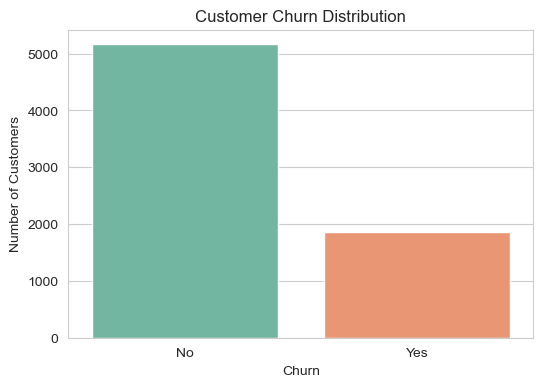

In [36]:
# Overall churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

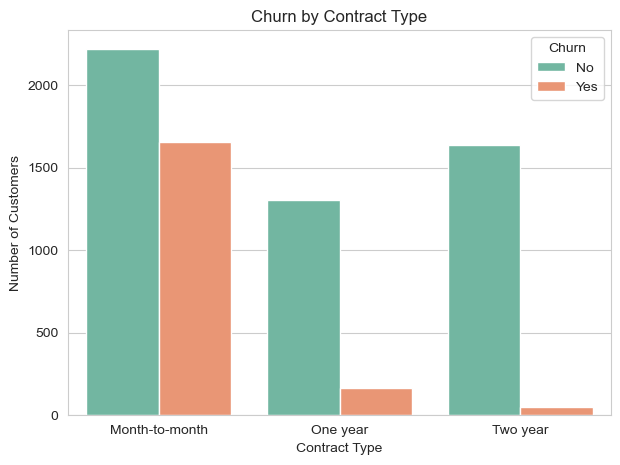

In [37]:
# Churn by contract type
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

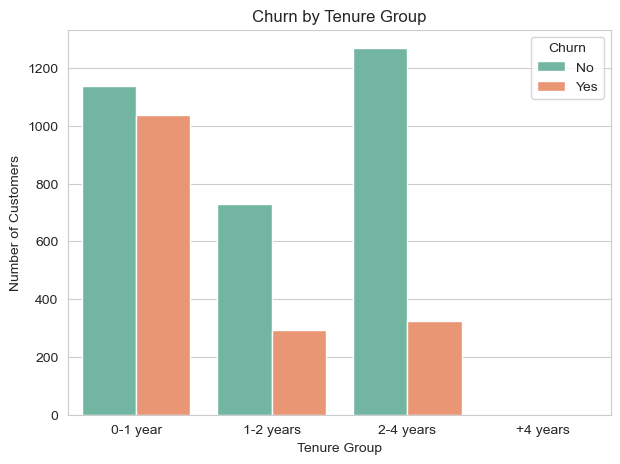

In [38]:
# Churn by tenure Group
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='TenureGroup', hue='Churn', order=['0-1 year', '1-2 years', '2-4 years', '+4 years'], palette='Set2')
plt.title('Churn by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Number of Customers')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_17248\2146342005.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')


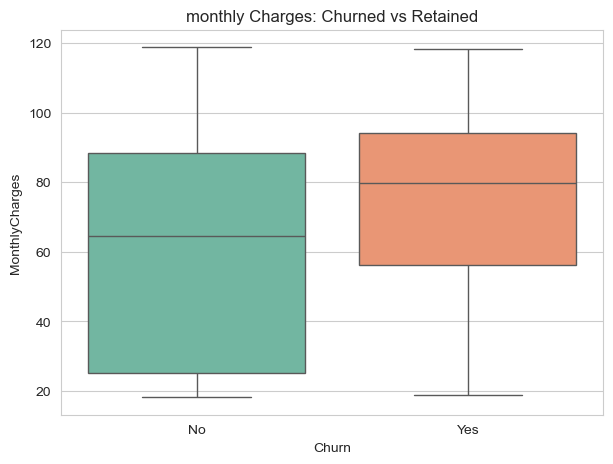

In [39]:
#Monthly charges - churned vs retained
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('monthly Charges: Churned vs Retained')
plt.show()

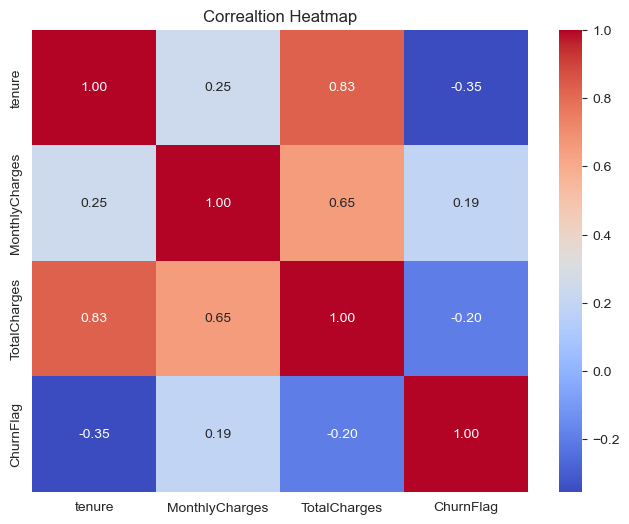

In [40]:
#Correaltion Heatmap
plt.figure(figsize=(8,6))
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges','ChurnFlag']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correaltion Heatmap')
plt.show()

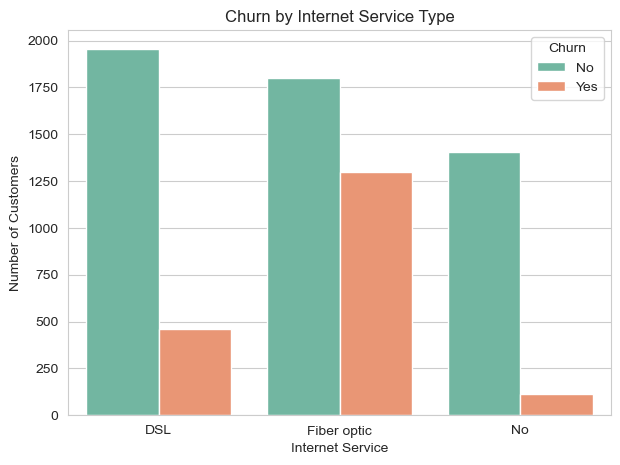

In [41]:
# Churn by Internet Service type
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set2')
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.show()

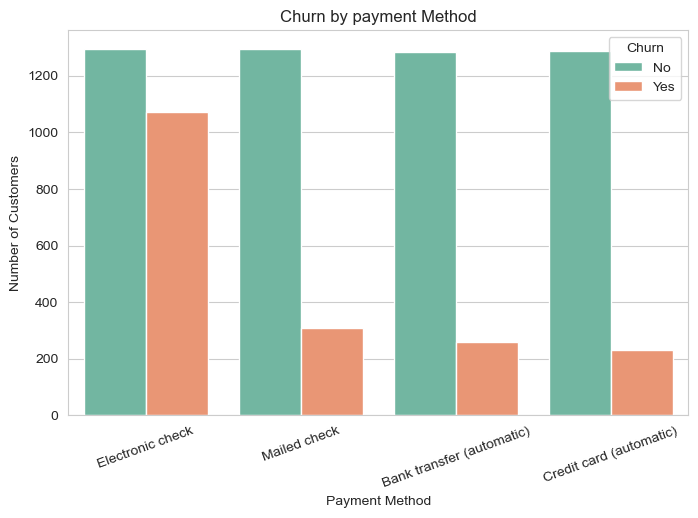

In [42]:
# Churn by Payment Method
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='Set2')
plt.title('Churn by payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.show()

In [43]:
df.to_csv('telco_churn_cleaned.csv', index=False)

In [44]:
import os
print(os.getcwd())

C:\Users\Acer\OneDrive\Desktop\cc2
